In [9]:
import numpy as np
import scipy as sp
import scipy.sparse, scipy.io, scipy.optimize
from scipy.special import expit

import matplotlib.pyplot as plt
import matplotlib as mpl
import time
%matplotlib inline

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a', # Color blind color cycle
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=CB_color_cycle) 

clip_01 = lambda M : np.clip(M, a_min=0, a_max=1)

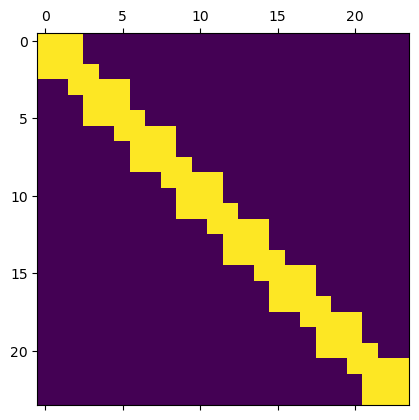

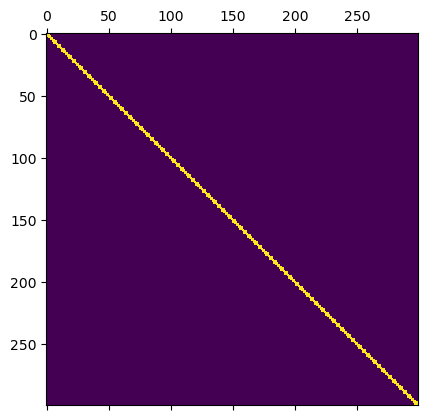

In [10]:
# Create the toy graph with n_tri triangles
def tri_path(n_tri, cycle=True, self_loops=True):
    tri_block = sp.sparse.coo_matrix([[0,1,1],[1,0,1],[1,1,0]])
    mat = sp.sparse.block_diag((tri_block,)*n_tri)
    diag = np.tile([0,0,1], n_tri)[:-1]
    mat += sp.sparse.diags([diag, diag], [-1,1])
    if cycle:
        mat[0,-1] = 1
        mat[-1,0] = 1
    if self_loops:
        mat += sp.sparse.identity(n_tri*3)
    return mat
adj = tri_path(100, cycle=True, self_loops=True)
plt.matshow(adj.todense()[:24,:][:,:24])
plt.matshow(adj.todense())

In [11]:
def lpca_loss(factors, adj_s, rank): # adj_s = shifted adj with -1's and +1's
    n_row, n_col = adj_s.shape
    U = factors[:n_row*rank].reshape(n_row, rank)
    V = factors[n_row*rank:].reshape(rank, n_col)
    logits = U @ V
    prob_wrong = expit(-logits * adj_s)
    loss = (np.logaddexp(0,-logits*adj_s)).sum()# / n_element    
    U_grad = -(prob_wrong * adj_s) @ V.T# / n_element
    V_grad = -U.T @ (prob_wrong * adj_s)# / n_element
    print(loss)
    return loss, np.concatenate((U_grad.flatten(), V_grad.flatten()))

In [12]:
rank_lpca = 5
rank_tsvd = 15

save_interval = 10

n_row, n_col = adj.shape
factors = -1+2*np.random.random(size=(np.sum(adj.shape)*rank_lpca)) # initalize uniformly on [-1,+1]
iter_num = 0
def callback_recm(x_i): # prints the loss and periodically saves the factors
    global iter_num
    iter_num += 1
    if iter_num % save_interval == 0:
        global factors, n_row, n_col, rank_lpca
        factors = x_i
        U = factors[:n_row*rank_lpca].reshape(n_row, rank_lpca)
        V = factors[n_row*rank_lpca:].reshape(rank_lpca, n_col)
        frob_error_norm = np.linalg.norm(clip_01(U@V) - adj) / sp.sparse.linalg.norm(adj)
        print(iter_num, "Frob_error_norm: ", frob_error_norm)

U = factors[:n_row*rank_lpca].reshape(n_row, rank_lpca)
V = factors[n_row*rank_lpca:].reshape(rank_lpca, n_col)
frob_error_norm = np.linalg.norm(1.*(U @ V > 0) - adj) / sp.sparse.linalg.norm(adj)
print(frob_error_norm)

6.394315657462706


In [13]:
res = scipy.optimize.minimize(lpca_loss, x0=factors, 
                              args=(-1 + 2*np.array(adj.todense()), rank_lpca), jac=True, method='L-BFGS-B', 
                              callback=callback_recm, 
                              options={'maxiter':2000}
                             )
factors = res.x
U = res.x[:n_row*rank_lpca].reshape(n_row, rank_lpca)
V = res.x[n_row*rank_lpca:].reshape(rank_lpca, n_col)
frob_error_norm = np.linalg.norm(clip_01(U@V) - adj) / sp.sparse.linalg.norm(adj)
print("Frob norm error: ", frob_error_norm)

68171.7501684592
67469.7999610356
65205.83059397996
56881.83949421096
25821.876706237752
10486.33677605427
7357.390965647586
6561.1121278792225
6086.429410335419
5849.157821069257
5630.112006348538
5306.729797854182
6825.3858761864285
5034.719828817353
10 Frob_error_norm:  0.997736689178241
6454.903683795116
4759.364660599792
4550.157835369263
4392.267703752261
3905.9289037531557
3615.064883401254
3327.4702293555856
3236.914454413778
3070.7951662055757
2948.719511219787
2686.3302623051704
2546.066084024051
20 Frob_error_norm:  0.8120622796150494
2348.0439227133843
2263.2892240303263
2121.6154705531094
2010.4628112654113
1925.598268008352
1866.8795138041096
1772.8002963461108
1691.6169507967977
1608.3790946728593
1538.549628425041
30 Frob_error_norm:  0.6438426090768482
1482.4500430769647
1427.1388477735636
1373.8507722503277
1307.828593288772
1257.3017225909562
1210.491884870172
1164.4978434378156
1132.0769563366375
1096.4566518069857
1067.046584832627
40 Frob_error_norm:  0.5139828965

In [14]:
# generate a rank k TSVD factorization of a small sparse matrix adj
def factor_TSVD(adj, k):
    w, v = np.linalg.eigh(np.array(adj.todense()))
    order = np.argsort(np.abs(w))[::-1]
    w = w[order[:k]]
    v = v[:,order[:k]]
    U_tsvd, V_tsvd = v * np.sqrt(np.abs(w))[None,:], (np.sign(w)*np.sqrt(np.abs(w)))[:,None] * v.T
    return U_tsvd, V_tsvd
U_tsvd, V_tsvd = factor_TSVD(adj, rank_tsvd)

In [15]:
# print the Frobenius errors of the LPCA and TSVD reconstructions, respectively 
print( np.linalg.norm(adj.todense() - expit(U@V)) / sp.sparse.linalg.norm(adj) )
print( np.linalg.norm(adj.todense() - clip_01(U_tsvd@V_tsvd)) / sp.sparse.linalg.norm(adj) )

0.05587908924383846
0.8941723051941602


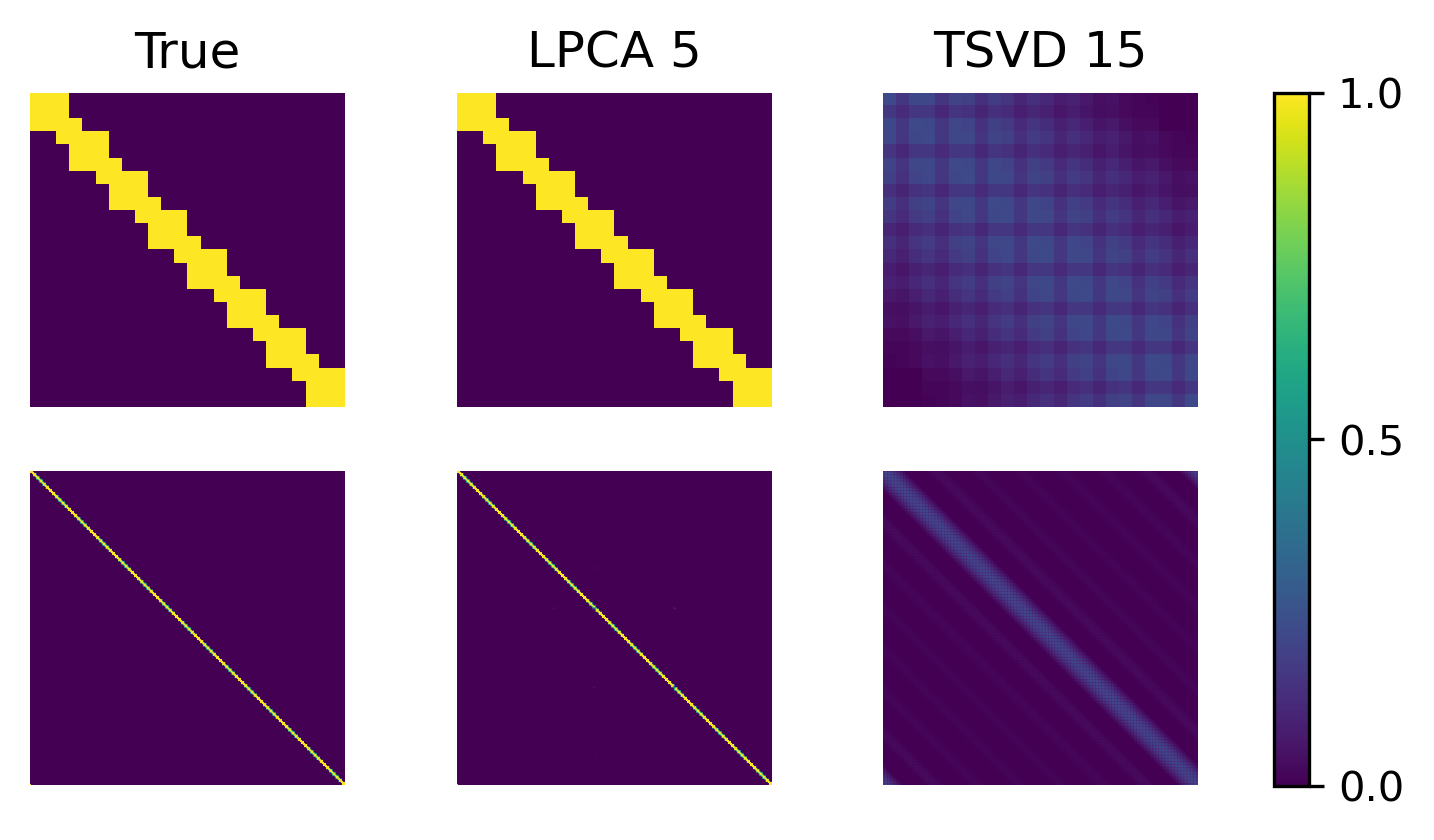

In [16]:
fig, axs = plt.subplots(2,3)
fig.set_size_inches(6.5,3)
fig.set_dpi(300)

im = axs[0,0].imshow(adj[:24,:][:,:24].todense(), vmin=0,vmax=1)
axs[0,0].set_axis_off()
axs[1,0].imshow(adj.todense(), vmin=0,vmax=1)
axs[1,0].set_axis_off()
axs[0,0].set_title('True')

axs[0,1].imshow(expit(U@V)[:24,:][:,:24], vmin=0,vmax=1)
axs[0,1].set_axis_off()
axs[1,1].imshow(expit(U@V), vmin=0,vmax=1)
axs[1,1].set_axis_off()
axs[0,1].set_title('LPCA ' + str(rank_lpca))

axs[0,2].imshow(np.clip(U_tsvd@V_tsvd, a_min=0, a_max=1)[:24,:][:,:24], vmin=0,vmax=1)
axs[0,2].set_axis_off()
axs[1,2].imshow(np.clip(U_tsvd@V_tsvd, a_min=0, a_max=1), vmin=0,vmax=1)
axs[1,2].set_axis_off()
axs[0,2].set_title('TSVD ' + str(rank_tsvd))

fig.colorbar(im, ax=axs.ravel().tolist(), ticks=[0, 0.5, 1], shrink=1.0)